In [2]:
# Load relevant modules
import postgkyl as pg
import numpy as np
import matplotlib.pyplot as plt
import os

# plt.rcParams["figure.figsize"] = (6, 5)
# plt.rcParams["font.size"] = 12


In [7]:
# Base directory where GKYL files live
basedir = "/dartfs-hpc/rc/home/7/f006xp7/gkeyll_tests/drift_wave_study_true/"

# Output step to load
step = 1


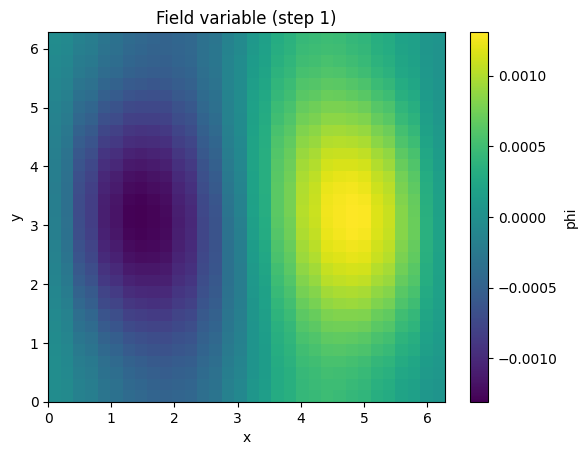

In [8]:
field = pg.data.GData(f"{basedir}/drift_wave_instability-field_{step}.gkyl")

finterp = pg.data.GInterpModal(field, 1, 'ms')
interpGrid, fld = finterp.interpolate()

x = interpGrid[0]
y = interpGrid[1]

phi = fld[:,:,0]

plt.figure()
plt.pcolormesh(x, y, phi.T, shading="auto")
plt.colorbar(label="phi")
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Field variable (step {step})")
plt.show()

max|rho| = 0.06578400153812436
mean rho = 0.04669849561143041


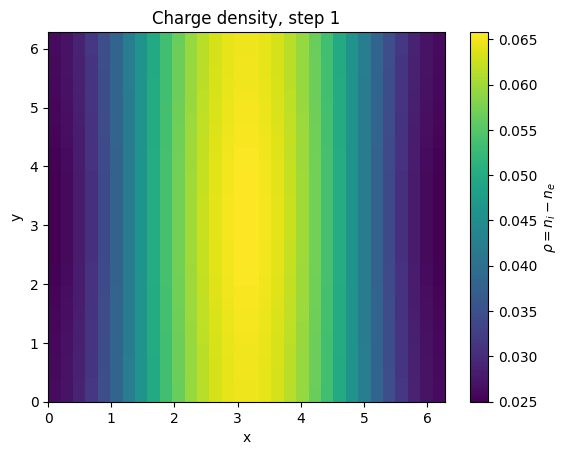

In [11]:
elc = pg.data.GData(f"{basedir}/drift_wave_instability-elc_M0_{step}.gkyl")
ei  = pg.data.GInterpModal(elc, 1, 'ms')
grid, ne_raw = ei.interpolate()
ne = ne_raw[:, :, 0]

ion = pg.data.GData(f"{basedir}/drift_wave_instability-ion_M0_{step}.gkyl")
ii  = pg.data.GInterpModal(ion, 1, 'ms')
grid, ni_raw = ii.interpolate()
ni = ni_raw[:, :, 0]

rho = -ne + ni

print("max|rho| =", np.max(np.abs(rho)))
print("mean rho =", np.mean(rho))

plt.figure()
plt.pcolormesh(grid[0], grid[1], rho.T, shading="auto")
plt.colorbar(label=r"$\rho = n_i - n_e$")
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Charge density, step {step}")
plt.show()

In [12]:
elc1 = pg.data.GData(f"{basedir}/drift_wave_instability-elc_M1_{step}.gkyl")
e1i  = pg.data.GInterpModal(elc1, 1, 'ms')
grid, m1e = e1i.interpolate()

ion1 = pg.data.GData(f"{basedir}/drift_wave_instability-ion_M1_{step}.gkyl")
i1i  = pg.data.GInterpModal(ion1, 1, 'ms')
grid, m1i = i1i.interpolate()

# assuming 2 velocity components
Jx = (-1.0)*m1e[:, :, 0] + (1.0)*m1i[:, :, 0]
Jy = (-1.0)*m1e[:, :, 1] + (1.0)*m1i[:, :, 1]

print("max|Jx| =", np.max(np.abs(Jx)))
print("max|Jy| =", np.max(np.abs(Jy)))

plt.figure()
plt.pcolormesh(grid[0], grid[1], Jx.T, shading="auto")
plt.colorbar(label=r"$J_x$")
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Current density $J_x$, step {step}")
plt.show()

plt.figure()
plt.pcolormesh(grid[0], grid[1], Jy.T, shading="auto")
plt.colorbar(label=r"$J_y$")
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Current density $J_y$, step {step}")
plt.show()

IndexError: index 1 is out of bounds for axis 2 with size 1

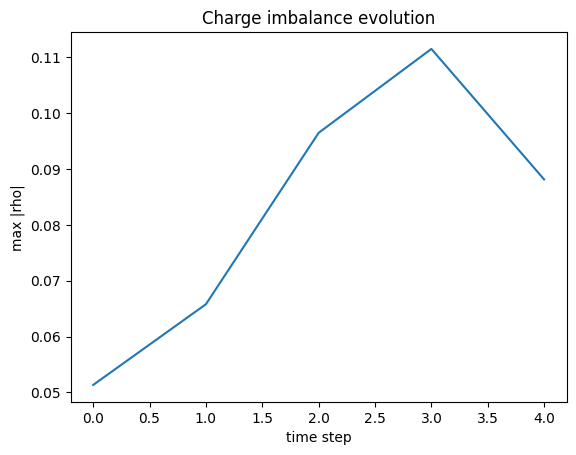

In [13]:
import glob

steps = sorted(glob.glob(f"{basedir}/drift_wave_instability-elc_M0_*.gkyl"))

rho_max = []

for f in steps:
    step = int(f.split("_")[-1].split(".")[0])

    elc = pg.data.GData(f"{basedir}/drift_wave_instability-elc_M0_{step}.gkyl")
    ion = pg.data.GData(f"{basedir}/drift_wave_instability-ion_M0_{step}.gkyl")

    ei = pg.data.GInterpModal(elc,1,'ms')
    ii = pg.data.GInterpModal(ion,1,'ms')

    _, ne = ei.interpolate()
    _, ni = ii.interpolate()

    rho = ni[:,:,0] - ne[:,:,0]

    rho_max.append(np.max(np.abs(rho)))

plt.plot(rho_max)
plt.xlabel("time step")
plt.ylabel("max |rho|")
plt.title("Charge imbalance evolution")
plt.show()

In [9]:
# -------------------------------------------------
# Load field data
# -------------------------------------------------

field = pg.data.GData(f"{basedir}/drift_wave_instability-field_{step}.gkyl")

finterp = pg.data.GInterpModal(field, 1, 'ms')
interpGrid, fld = finterp.interpolate()

x = interpGrid[0]
y = interpGrid[1]

# Field components
Ex = fld[:,:,0]
Ey = fld[:,:,1]
Ez = fld[:,:,2]

Bx = fld[:,:,3]
By = fld[:,:,4]
Bz = fld[:,:,5]

dx = x[1] - x[0]
dy = y[1] - y[0]

IndexError: index 1 is out of bounds for axis 2 with size 1

In [10]:
field = pg.data.GData(f"{basedir}/drift_wave_instability-field_{step}.gkyl")
finterp = pg.data.GInterpModal(field, 1, 'ms')
interpGrid, fld = finterp.interpolate()

print("fld.shape =", fld.shape)
print("ndim =", fld.ndim)

if fld.ndim == 3:
    print("ncomp =", fld.shape[2])
    for c in range(fld.shape[2]):
        arr = fld[:, :, c]
        print(f"comp {c}: min={arr.min():.6e}, max={arr.max():.6e}")

fld.shape = (32, 32, 1)
ndim = 3
ncomp = 1
comp 0: min=-1.308415e-03, max=1.308415e-03


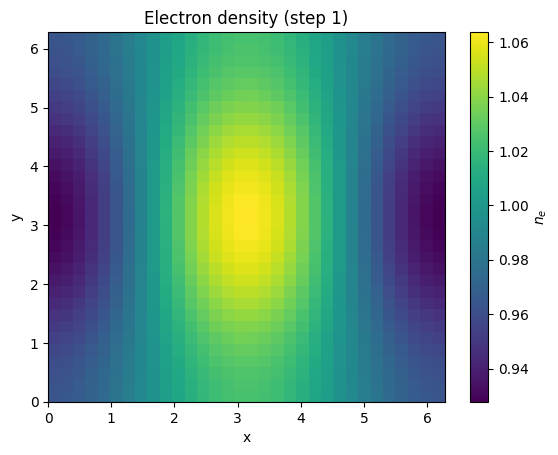

In [11]:
# Load electron density moment (modal data!)
elc_m0 = pg.data.GData(f"{basedir}/drift_wave_instability-elc_M0_{step}.gkyl")

# Interpolate modal → nodal
# polyOrder = 1, basis = serendipity
m0Interp = pg.data.GInterpModal(elc_m0, 1, 'ms')
interpGrid, ne = m0Interp.interpolate()

# interpGrid = [x, y]
x = interpGrid[0]
y = interpGrid[1]

# ne shape: (Nx, Ny, 1)
ne2d = ne[:, :, 0]

plt.figure()
plt.pcolormesh(x, y, ne2d.T, shading="auto")
plt.colorbar(label=r"$n_e$")
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Electron density (step {step})")
plt.show()


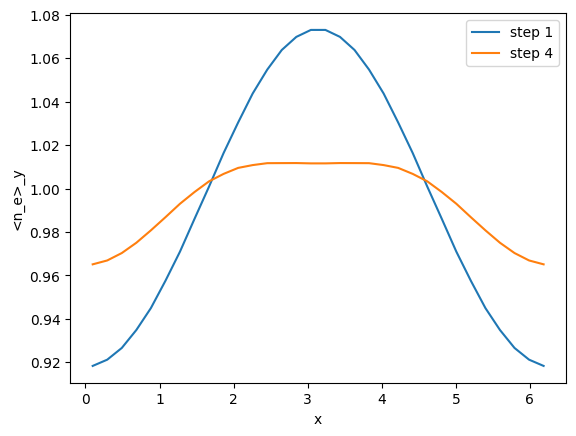

In [5]:
def load_ne(step):
    elc_m0 = pg.data.GData(f"{basedir}/drift_wave_instability-elc_M0_{step}.gkyl")
    m0Interp = pg.data.GInterpModal(elc_m0, 1, 'ms')
    interpGrid, ne = m0Interp.interpolate()
    ne2d = ne[:, :, 0]
    x = interpGrid[0]
    y = interpGrid[1]
    return x, y, ne2d

x, y, ne1 = load_ne(1)
x, y, ne4 = load_ne(4)

p1 = np.mean(ne1, axis=1)
p4 = np.mean(ne4, axis=1)

# convert edges -> centers
x_centers = 0.5*(x[:-1] + x[1:])

plt.figure()
plt.plot(x_centers, p1, label="step 1")
plt.plot(x_centers, p4, label="step 4")
plt.xlabel("x")
plt.ylabel("<n_e>_y")
plt.legend()
plt.show()

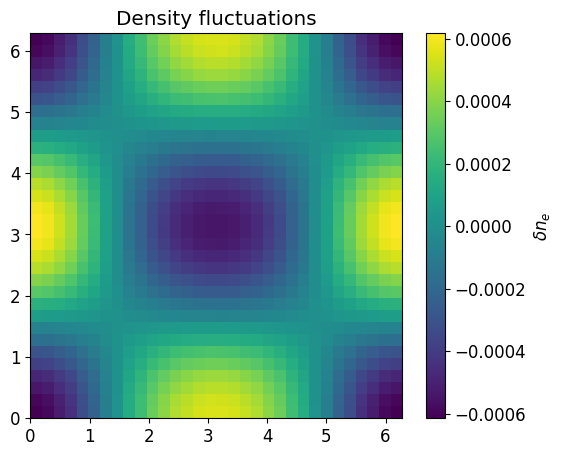

In [4]:
ne_fluc = ne2d - ne2d.mean(axis=1, keepdims=True)

plt.figure()
plt.pcolormesh(x, y, ne_fluc.T, shading="auto")
plt.colorbar(label=r"$\delta n_e$")
plt.title("Density fluctuations")
plt.show()


In [6]:
import postgkyl as pg
import numpy as np
import matplotlib.pyplot as plt

def load_gkyl_interp(path, polyOrder=1, basis="ms"):
    """Load a .gkyl file and return (grid_list, values_array) after modal->nodal interpolation."""
    gd = pg.data.GData(path)
    gi = pg.data.GInterpModal(gd, polyOrder, basis)
    grid, vals = gi.interpolate()
    return grid, vals

def pcolor_xy(x, y, A, title, cbar_label):
    plt.figure(figsize=(6,5))
    plt.pcolormesh(x, y, A.T, shading="auto")
    plt.colorbar(label=cbar_label)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.show()


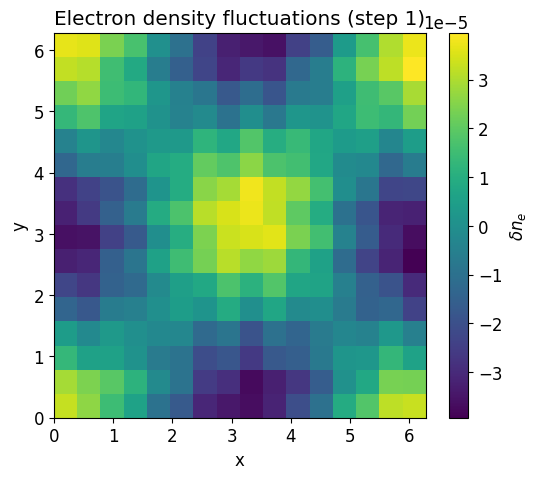

In [7]:
basedir = "/dartfs-hpc/rc/home/7/f006xp7/gkeyll_tests/weibel_2x2v"
step = 1

grid, ne = load_gkyl_interp(f"{basedir}/drift_wave_instability-elc_M0_{step}.gkyl", polyOrder=1, basis="ms")
x, y = grid[0], grid[1]
ne2d = ne[:, :, 0]

# remove y-mean at each x to isolate fluctuations
dne = ne2d - ne2d.mean(axis=1, keepdims=True)

pcolor_xy(x, y, dne, f"Electron density fluctuations (step {step})", r"$\delta n_e$")


In [10]:
print("fld shape:", fld.shape)


fld shape: (16, 16, 1)


In [6]:
print("Field array shape:", fld.shape)

if fld.shape[2] == 1:
    # Reduced field output
    Ey = fld[:, :, 0]
else:
    # Full Maxwell output
    Ey = fld[:, :, 1]

pcolor_xy(x_f, y_f, Ey, f"$E_y$ (step {step})", r"$E_y$")


NameError: name 'fld' is not defined

In [12]:
import postgkyl as pg
import numpy as np
import matplotlib.pyplot as plt

def load_interp(path, polyOrder=1, basis="ms"):
    gd = pg.data.GData(path)
    gi = pg.data.GInterpModal(gd, polyOrder, basis)
    grid, vals = gi.interpolate()
    return grid, vals

def pcolor_xy(x, y, A, title, cbar_label):
    plt.figure(figsize=(6,5))
    plt.pcolormesh(x, y, A.T, shading="auto")
    plt.colorbar(label=cbar_label)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.show()

def get_comp(arr, idx, name="comp"):
    """
    Return arr[:,:,idx] if it exists, else None.
    Works when arr is (Nx,Ny,ncomp) or (Nx,Ny) or (Nx,Ny,1).
    """
    if arr.ndim == 2:
        if idx == 0:
            return arr
        print(f"[WARN] {name}: array is 2D, no component {idx}.")
        return None

    ncomp = arr.shape[2]
    if idx < ncomp:
        return arr[:, :, idx]
    print(f"[WARN] {name}: requested component {idx} but only {ncomp} component(s) exist.")
    return None


In [13]:
basedir = "/dartfs-hpc/rc/home/7/f006xp7/gkeyll_tests/weibel_2x2v"
step = 1

grid_f, fld = load_interp(f"{basedir}/drift_wave_instability-field_{step}.gkyl", polyOrder=1, basis="ms")
x_f, y_f = grid_f[0], grid_f[1]

print("Field array shape:", fld.shape)


Field array shape: (16, 16, 1)


In [14]:
Ex = get_comp(fld, 0, "E")
Ey = get_comp(fld, 1, "E")
Ez = get_comp(fld, 2, "E")
Bx = get_comp(fld, 3, "B")
By = get_comp(fld, 4, "B")
Bz = get_comp(fld, 5, "B")


[WARN] E: requested component 1 but only 1 component(s) exist.
[WARN] E: requested component 2 but only 1 component(s) exist.
[WARN] B: requested component 3 but only 1 component(s) exist.
[WARN] B: requested component 4 but only 1 component(s) exist.
[WARN] B: requested component 5 but only 1 component(s) exist.


In [1]:
# Load some relevant modules for this exercise
import postgkyl as pg
import imageio.v2 as imageio
import matplotlib.pyplot as plt
import os
import numpy as np


In [2]:
# Select which output step to load
step = 1

# Load electron distribution function data from a Gkeyll output file
# This file was generated using a serendipity basis with poly_order = 2
# elc = pg.data.GData(f'/dartfs-hpc/rc/home/7/f007gj7/data/TWO_GK2/rt_vlasov_twostream_p2-elc_{step}.gkyl')
elc = pg.data.GData(f'/dartfs-hpc/rc/home/7/f006xp7/p118_project/rt_vlasov_twostream_p2-elc_{step}.gkyl')

# Set up modal-to-nodal interpolation of the distribution function
# Arguments:
#   - elc:        input Gkeyll data object
#   - 2:          polynomial order used in the simulation (poly_order)
#   - 'ms':       modal serendipity basis
elc_Interp = pg.data.GInterpModal(elc, 1, 'ms')

# Interpolate the modal data onto a uniform nodal grid
# interpGrid_elc contains the phase-space grid coordinates
# f_elc contains the interpolated distribution function values
interpGrid_elc, f_elc = elc_Interp.interpolate()
f_elc = f_elc[:, :, 0]

In [3]:
print("interpGrid lengths:", len(interpGrid_elc))
for i,g in enumerate(interpGrid_elc):
    print(i, np.array(g).shape, (np.array(g)[0], np.array(g)[-1]))

print("f_elc shape:", f_elc.shape)  # expect (1, Nx, Nvx, Nvy)


interpGrid lengths: 4
0 (33,) (-20.0, 20.0)
1 (33,) (-20.0, 20.0)
2 (17,) (-6.0, 6.0)
3 (17,) (-6.0, 6.0)
f_elc shape: (32, 32, 16, 1)


In [5]:
f = f_elc  # shape (Nx, Ny, Nv, 1)
f = f[..., 0]  # drop trivial last dim → (Nx, Ny, Nv)

ix = f.shape[0] // 2
f_yv = f[ix, :, :]   # (Ny, Nv)

y  = np.array(interpGrid_elc[1])
v  = np.array(interpGrid_elc[2])

plt.figure(figsize=(5,4))
plt.imshow(
    f_yv.T,
    origin="lower",
    aspect="auto",
    extent=[y[0], y[-1], v[0], v[-1]],
    cmap="inferno"
)
plt.xlabel(r"$y$")
plt.ylabel(r"$v$")
plt.title(r"$f_e(y,v)$ at mid $x$")
plt.colorbar()
plt.show()


NameError: name 'f_elc' is not defined

TypeError: Invalid shape (16, 32, 32) for image data

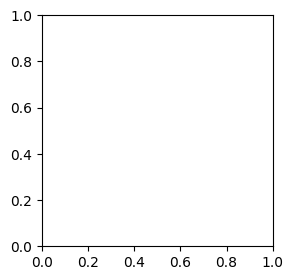

In [6]:
for step in [1, 10, 30, 60]:
    elc = pg.data.GData(f'rt_vlasov_twostream_p2-elc_{step}.gkyl')
    elcI = pg.data.GInterpModal(elc, 1, 'ms')
    grid, f_elc = elcI.interpolate()
    f = f_elc[...,0]
    n_xy = np.sum(f, axis=2)

    plt.figure(figsize=(4,3))
    plt.imshow(n_xy.T, origin="lower",
               extent=[x[0],x[-1],y[0],y[-1]],
               cmap="viridis")
    plt.title(f"step = {step}")
    plt.colorbar()
    plt.show()


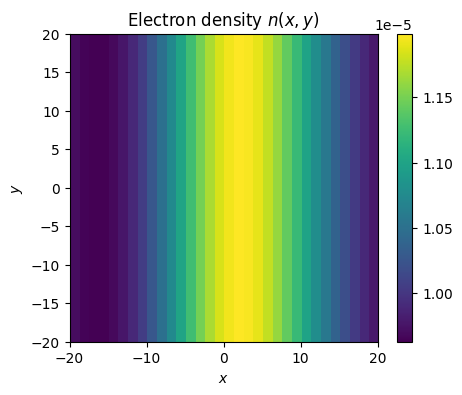

In [5]:
# Integrate over velocity
n_xy = np.sum(f, axis=2)   # (Nx, Ny)

x = np.array(interpGrid_elc[0])
y = np.array(interpGrid_elc[1])

plt.figure(figsize=(5,4))
plt.imshow(
    n_xy.T,
    origin="lower",
    extent=[x[0], x[-1], y[0], y[-1]],
    cmap="viridis"
)
plt.xlabel(r"$x$")
plt.ylabel(r"$y$")
plt.title("Electron density $n(x,y)$")
plt.colorbar()
plt.show()


TypeError: Invalid shape (1, 16, 32, 32) for image data

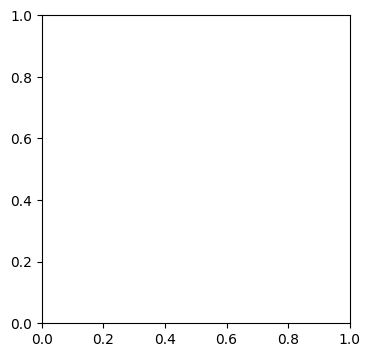

In [5]:
fig = plt.figure(figsize=(8, 4), dpi=100, facecolor='white')
ax = plt.subplot(111)

ax.imshow(f_elc.T, extent=(interpGrid_elc[0][0], interpGrid_elc[0][-1], interpGrid_elc[1][0], interpGrid_elc[1][-1]), origin='lower', cmap='inferno')
ax.set_xlabel(r"$x / \lambda_D$")
ax.set_ylabel(r"$v_x / v_{te}$")
dt = 200.0 / 500  # = 0.4
t = step * dt

ax.set_title(rf"$f_e(x,v)$, $t\,\omega_{{pe}} = {t:.1f}$")

ax.set_aspect('auto')

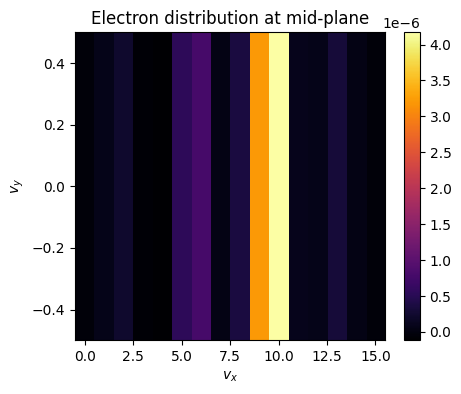

In [6]:
# f_elc has shape (1, Nx, Nvx, Nvy)
f = f_elc[0]  # drop component index → (Nx, Nvx, Nvy)

ix = f.shape[0] // 2   # x index (center)
f_v = f[ix, :, :]     # (Nvx, Nvy)

plt.figure(figsize=(5,4))
plt.imshow(
    f_v.T,
    origin="lower",
    aspect="auto",
    cmap="inferno"
)
plt.xlabel(r"$v_x$")
plt.ylabel(r"$v_y$")
plt.title("Electron distribution at mid-plane")
plt.colorbar()
plt.show()


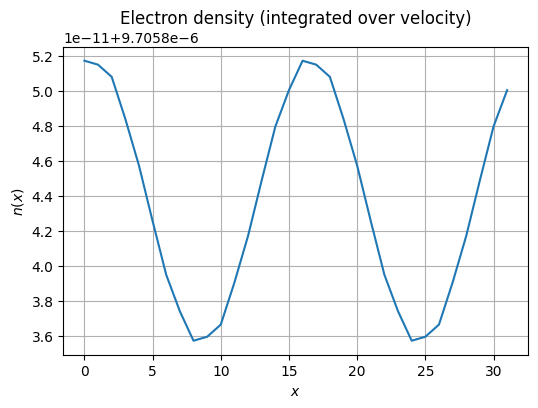

In [8]:
# f_elc shape: (1, Nx, Nvx, Nvy)
f = f_elc[0]

# Integrate over velocity space
n_x = np.sum(f, axis=(1,2))   # shape (Nx,)

plt.figure(figsize=(6,4))
plt.plot(n_x)
plt.xlabel(r"$x$")
plt.ylabel(r"$n(x)$")
plt.title("Electron density (integrated over velocity)")
plt.grid(True)
plt.show()


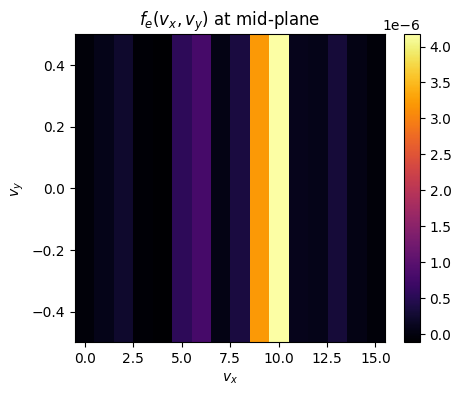

In [9]:
ix = f.shape[0] // 2   # mid x
f_v = f[ix, :, :]     # (Nvx, Nvy)

plt.figure(figsize=(5,4))
plt.imshow(
    f_v.T,
    origin="lower",
    cmap="inferno",
    aspect="auto"
)
plt.xlabel(r"$v_x$")
plt.ylabel(r"$v_y$")
plt.title(r"$f_e(v_x,v_y)$ at mid-plane")
plt.colorbar()
plt.show()


In [11]:
# Load electric field data from the Gkeyll output file
# This file contains the DG representation of the electromagnetic field
e = pg.data.GData(
    f'/dartfs-hpc/rc/home/7/f006xp7/hw3/data/rt_vlasov_twostream_p2-field_{step}.gkyl'
)

# Set up the interpolator for the field data
# As above:
#   - poly_order = 2
#   - 'ms' indicates a serendipity basis
e_Interp = pg.data.GInterpModal(e, 2, 'ms')

# Interpolate only component 0 of the field (Ex in 1D)
# interpGrid contains the spatial grid
# exs contains the interpolated electric field values
interpGrid, exs = e_Interp.interpolate(0)

# Drop the extra dimension so exs is a 1D array over space
exs = exs[:, 0]

# Construct cell-centered spatial grid from cell edge coordinates
# interpGrid[0] contains the x-grid edges
ex_grid = (interpGrid[0][1:] + interpGrid[0][:-1]) / 2

# Compute the grid spacing dx (uniform grid assumed)
dx = np.diff(ex_grid)[0]

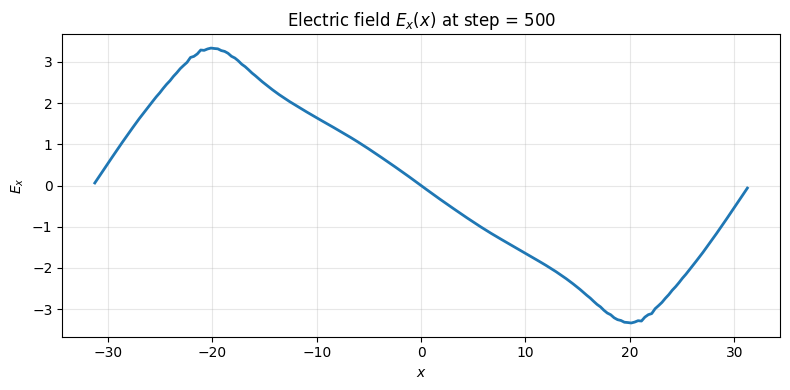

In [12]:
fig, ax = plt.subplots(figsize=(8, 4), dpi=100)

ax.plot(ex_grid, exs, lw=2)
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$E_x$")
ax.set_title(f"Electric field $E_x(x)$ at step = {step}")

ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Movie

In [19]:
# Movie parameters
stride = 5
first_step = 0
last_step = 500

dt = 200.0 / 500  # time normalization (ω_pe^{-1})

data_dir = "/dartfs-hpc/rc/home/7/f006xp7/hw3/data"
frame_dir = "frames"
os.makedirs(frame_dir, exist_ok=True)


In [20]:
for step in range(first_step, last_step + 1, stride):

    # Load distribution function
    elc = pg.data.GData(
        f"{data_dir}/rt_vlasov_twostream_p2-elc_{step}.gkyl"
    )

    elc_Interp = pg.data.GInterpModal(elc, 2, 'ms')
    interpGrid_elc, f_elc = elc_Interp.interpolate()
    f_elc = f_elc[:, :, 0]

    # Time in ω_pe^{-1}
    t = step * dt

    # Plot
    fig, ax = plt.subplots(figsize=(8, 4), dpi=100)

    im = ax.imshow(
        f_elc.T,
        extent=(interpGrid_elc[0][0], interpGrid_elc[0][-1],
                interpGrid_elc[1][0], interpGrid_elc[1][-1]),
        origin='lower',
        cmap='inferno',
        aspect='auto'
    )

    ax.set_xlabel(r"$x / \lambda_D$")
    ax.set_ylabel(r"$v_x / v_{te}$")
    ax.set_title(rf"$f_e(x,v)$, $t\,\omega_{{pe}} = {t:.1f}$")

    plt.tight_layout()

    # Save frame
    fname = f"{frame_dir}/frame_{step:04d}.png"
    plt.savefig(fname)
    plt.close(fig)

    print(f"Saved {fname}")


Saved frames/frame_0000.png
Saved frames/frame_0005.png
Saved frames/frame_0010.png
Saved frames/frame_0015.png
Saved frames/frame_0020.png
Saved frames/frame_0025.png
Saved frames/frame_0030.png
Saved frames/frame_0035.png
Saved frames/frame_0040.png
Saved frames/frame_0045.png
Saved frames/frame_0050.png
Saved frames/frame_0055.png
Saved frames/frame_0060.png
Saved frames/frame_0065.png
Saved frames/frame_0070.png
Saved frames/frame_0075.png
Saved frames/frame_0080.png
Saved frames/frame_0085.png
Saved frames/frame_0090.png
Saved frames/frame_0095.png
Saved frames/frame_0100.png
Saved frames/frame_0105.png
Saved frames/frame_0110.png
Saved frames/frame_0115.png
Saved frames/frame_0120.png
Saved frames/frame_0125.png
Saved frames/frame_0130.png
Saved frames/frame_0135.png
Saved frames/frame_0140.png
Saved frames/frame_0145.png
Saved frames/frame_0150.png
Saved frames/frame_0155.png
Saved frames/frame_0160.png
Saved frames/frame_0165.png
Saved frames/frame_0170.png
Saved frames/frame_0

In [21]:
gif_name = "twostream_phase_space.gif"

frames = []
for step in range(first_step, last_step + 1, stride):
    fname = f"{frame_dir}/frame_{step:04d}.png"
    frames.append(imageio.imread(fname))

imageio.mimsave(gif_name, frames, fps=5)


# Energy Curves

In [26]:
E = pg.data.GData("data/rt_vlasov_twostream_p2-field-energy.gkyl")

In [46]:
import postgkyl as pg
import numpy as np
import matplotlib.pyplot as plt

E = pg.data.GData("data/rt_vlasov_twostream_p2-field-energy.gkyl")

# THIS is the correct call for nodal diagnostics
grid, vals = E.read()

t = grid[0]

# vals shape = (Nt, 6)
# 0 Ex^2, 1 Ey^2, 2 Ez^2, 3 Bx^2, 4 By^2, 5 Bz^2
E_elec = vals[:,0] + vals[:,1] + vals[:,2]


AttributeError: 'GData' object has no attribute 'read'

In [49]:
import postgkyl as pg
E = pg.data.GData("data/rt_vlasov_twostream_p2-field-energy.gkyl")
dir(E)


['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_comp_grid',
 '_custom_label',
 '_file_name',
 '_grid',
 '_label',
 '_mapc2p_name',
 '_mapc2p_vel_name',
 '_neighbors',
 '_reader',
 '_status',
 '_tag',
 '_values',
 '_var_name',
 'activate',
 'bounds',
 'color',
 'ctx',
 'deactivate',
 'get_bounds',
 'get_custom_label',
 'get_grid',
 'get_grid_type',
 'get_input_file',
 'get_label',
 'get_num_cells',
 'get_num_comps',
 'get_num_dims',
 'get_status',
 'get_tag',
 'get_values',
 'grid',
 'info',
 'label',
 'num_cells',
 'num_comps',
 'num_dims',
 'push',
 'set_grid',
 'set_label',
 'set_neighbors',
 'set_tag',
 'set_values',
 'status',
 'tag',
 'values',
 'write']

In [56]:
print(E._var_name)
print(E.label)


CartGridField



In [57]:
print("num_dims =", E.get_num_dims())
print("num_comps =", E.get_num_comps())
print("grid type =", E.get_grid_type())


num_dims = 1
num_comps = 6
grid type = nodal


In [58]:
print(vals[:3])


[[3.1415926535897932e-09 0.0000000000000000e+00 0.0000000000000000e+00
  0.0000000000000000e+00 0.0000000000000000e+00 0.0000000000000000e+00]
 [3.1414972737300014e-09 0.0000000000000000e+00 0.0000000000000000e+00
  0.0000000000000000e+00 0.0000000000000000e+00 0.0000000000000000e+00]
 [3.1412111473434310e-09 0.0000000000000000e+00 0.0000000000000000e+00
  0.0000000000000000e+00 0.0000000000000000e+00 0.0000000000000000e+00]]


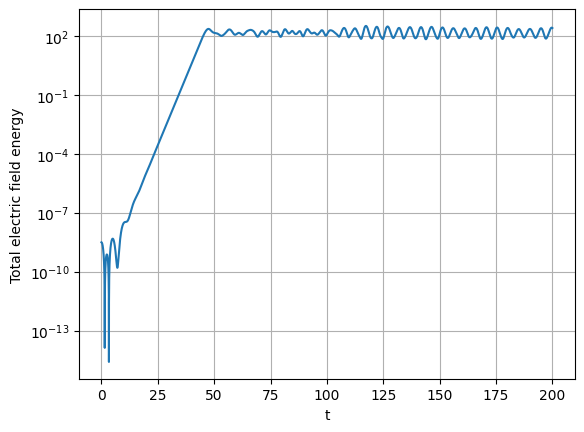

In [51]:
import postgkyl as pg
import numpy as np
import matplotlib.pyplot as plt

E = pg.data.GData("data/rt_vlasov_twostream_p2-field-energy.gkyl")

# Get grid and values
grid = E.get_grid()
vals = E.get_values()

t = grid[0]

# Total electric field energy
E_elec = vals[:, 0] + vals[:, 1] + vals[:, 2]

plt.figure()
plt.semilogy(t, E_elec)
plt.xlabel("t")
plt.ylabel("Total electric field energy")
plt.grid(True)
plt.show()


# Drifts compare

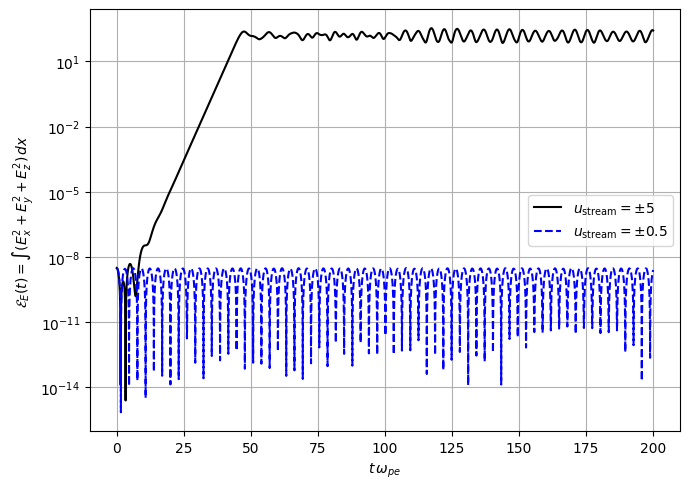

In [71]:

# --------------------------------------------------
# Full paths: SAME resolution, DIFFERENT drift speed
# --------------------------------------------------
path_u5   = "/dartfs-hpc/rc/home/7/f006xp7/hw3/data/rt_vlasov_twostream_p2-field-energy.gkyl"
path_u05  = "/dartfs-hpc/rc/home/7/f006xp7/hw3_u0p5/data/rt_vlasov_twostream_p2-field-energy.gkyl"

# --------------------------------------------------
# u_stream = ±5
# --------------------------------------------------
E5 = pg.data.GData(path_u5)
grid5 = E5.get_grid()
vals5 = E5.get_values()

t5 = grid5[0]
Eelec5 = vals5[:, 0] + vals5[:, 1] + vals5[:, 2]

# --------------------------------------------------
# u_stream = ±0.5
# --------------------------------------------------
E05 = pg.data.GData(path_u05)
grid05 = E05.get_grid()
vals05 = E05.get_values()

t05 = grid05[0]
Eelec05 = vals05[:, 0] + vals05[:, 1] + vals05[:, 2]

# --------------------------------------------------
# Plot comparison
# --------------------------------------------------
plt.figure(figsize=(7,5))
plt.semilogy(t5,  Eelec5, color = "black",  label=r"$u_{\rm stream}=\pm 5$")
plt.semilogy(t05, Eelec05, "--", color = "blue",  label=r"$u_{\rm stream}=\pm 0.5$")

plt.xlabel(r"$t\,\omega_{pe}$")
plt.ylabel(r"$\mathcal{E}_E(t) = \int (E_x^2 + E_y^2 + E_z^2)\,dx$")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("electric_field_energy_drifts.png", dpi=600, bbox_inches="tight")
plt.show()


# Resolution compare

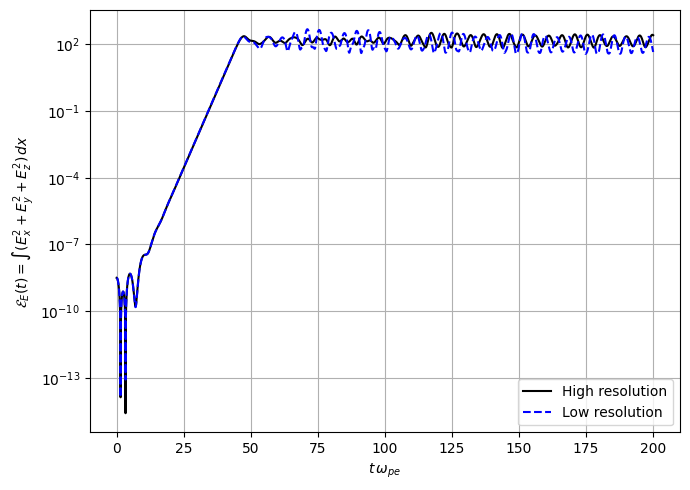

In [72]:
import postgkyl as pg
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Full paths to both runs
# ----------------------------
path_high = "/dartfs-hpc/rc/home/7/f006xp7/hw3/data/rt_vlasov_twostream_p2-field-energy.gkyl"
path_low  = "/dartfs-hpc/rc/home/7/f006xp7/hw3_lowres/data/rt_vlasov_twostream_p2-field-energy.gkyl"
# OR, if using hw3_u0p5 instead:
# path_low = "/dartfs-hpc/rc/home/7/f006xp7/hw3_u0p5/data/rt_vlasov_twostream_p2-field-energy.gkyl"

# ----------------------------
# Load HIGH resolution
# ----------------------------
E_hi = pg.data.GData(path_high)
grid_hi = E_hi.get_grid()
vals_hi = E_hi.get_values()
t_hi = grid_hi[0]
Eelec_hi = vals_hi[:, 0] + vals_hi[:, 1] + vals_hi[:, 2]

# ----------------------------
# Load LOW resolution
# ----------------------------
E_lo = pg.data.GData(path_low)
grid_lo = E_lo.get_grid()
vals_lo = E_lo.get_values()
t_lo = grid_lo[0]
Eelec_lo = vals_lo[:, 0] + vals_lo[:, 1] + vals_lo[:, 2]

# ----------------------------
# Plot comparison
# ----------------------------
plt.figure(figsize=(7,5))
plt.semilogy(t_hi, Eelec_hi, color = "black",  label="High resolution")
plt.semilogy(t_lo, Eelec_lo, "--", color = "blue",  label="Low resolution")
plt.xlabel(r"$t\,\omega_{pe}$")
plt.ylabel(r"$\mathcal{E}_E(t) = \int (E_x^2 + E_y^2 + E_z^2)\,dx$")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("electric_field_energy_resolution.png", dpi=600, bbox_inches="tight")
plt.show()


In [62]:
E = pg.data.GData("/dartfs-hpc/rc/home/7/f006xp7/hw3/data/rt_vlasov_twostream_p2-field-energy.gkyl")
grid = E.get_grid()
vals = E.get_values()
t = grid[0]
Eelec = vals[:,0] + vals[:,1] + vals[:,2]

print("t[0:5] =", t[:5])
print("Eelec[0:5] =", Eelec[:5])


t[0:5] = [0.                 0.0049087371841961 0.0098174743684024
 0.0147262115526492 0.0196349487369772]
Eelec[0:5] = [3.1415926535897932e-09 3.1414972737300014e-09 3.1412111473434310e-09
 3.1407343120779870e-09 3.1400668306745017e-09]


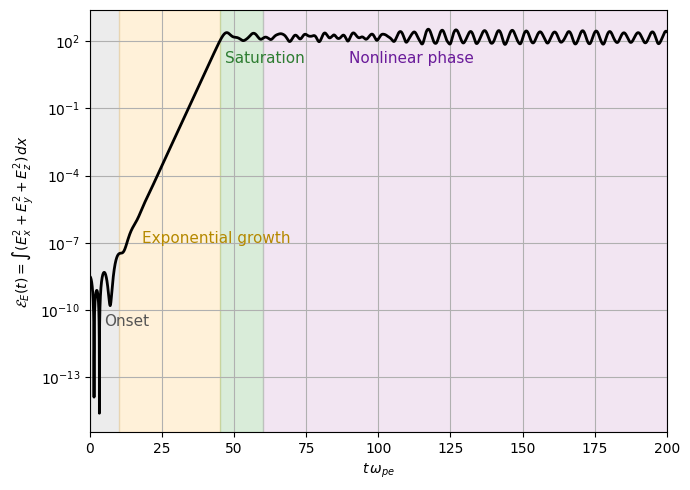

In [12]:
import postgkyl as pg
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Full path: u_stream = ±5
# --------------------------------------------------
path_u5 = "/dartfs-hpc/rc/home/7/f006xp7/hw3/data/rt_vlasov_twostream_p2-field-energy.gkyl"

E5 = pg.data.GData(path_u5)
grid5 = E5.get_grid()
vals5 = E5.get_values()

t5 = grid5[0]
Eelec5 = vals5[:, 0] + vals5[:, 1] + vals5[:, 2]

# --------------------------------------------------
# Figure
# --------------------------------------------------
plt.figure(figsize=(7, 5))
plt.semilogy(t5, Eelec5, color="black", lw=2)

plt.xlabel(r"$t\,\omega_{pe}$")
plt.ylabel(r"$\mathcal{E}_E(t) = \int (E_x^2 + E_y^2 + E_z^2)\,dx$")
plt.grid(True)

# --------------------------------------------------
# Phase background spans
# --------------------------------------------------
plt.axvspan(0, 10,  color="gray",   alpha=0.15)   # Onset
plt.axvspan(10, 45, color="orange", alpha=0.15)  # Exponential growth
plt.axvspan(45, 60, color="green",  alpha=0.15)  # Saturation
plt.axvspan(60, 200,color="purple", alpha=0.10)  # Nonlinear phase

# --------------------------------------------------
# Phase label colors (darkened versions)
# --------------------------------------------------
phase_colors = {
    "onset":      "#555555",
    "growth":     "#b58900",
    "saturation": "#2e7d32",
    "nonlinear":  "#6a1b9a",
}

bbox_kw = dict(facecolor="white", edgecolor="none", alpha=0.85)

# --------------------------------------------------
# Text annotations
# --------------------------------------------------
plt.text(5,  2e-11, "Onset",
         fontsize=11, color=phase_colors["onset"])

plt.text(18, 1e-7, "Exponential growth",
         fontsize=11, color=phase_colors["growth"])

plt.text(47, 1e1, "Saturation",
         fontsize=11, color=phase_colors["saturation"])

plt.text(90, 1e1, "Nonlinear phase",
         fontsize=11, color=phase_colors["nonlinear"])
plt.xlim(0,200)

# --------------------------------------------------
# Save + show
# --------------------------------------------------
plt.tight_layout()
plt.savefig("electric_field_energy_u5.png", dpi=600, bbox_inches="tight")
plt.show()


In [4]:
import os
import postgkyl as pg
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Simulation parameters
# -----------------------------
first_step = 0
last_step  = 500
mid_step   = last_step // 2

dt = 200.0 / 500  # time normalization (ω_pe^{-1})

data_dir  = "/dartfs-hpc/rc/home/7/f006xp7/hw3_lowres/data"
frame_dir = "frames"
os.makedirs(frame_dir, exist_ok=True)

# Steps to save
steps = {
    "t0": first_step,
    "tmid": mid_step,
    "tend": last_step
}

# -----------------------------
# Loop over selected steps only
# -----------------------------
for tag, step in steps.items():

    # Load distribution function
    elc = pg.data.GData(
        f"{data_dir}/rt_vlasov_twostream_p2-elc_{step}.gkyl"
    )

    # Modal → nodal interpolation
    elc_interp = pg.data.GInterpModal(elc, 2, "ms")
    interpGrid, f_elc = elc_interp.interpolate()

    # Extract distribution (single configuration dimension)
    f_elc = f_elc[:, :, 0]

    # Time
    t = step * dt

    # -----------------------------
    # Plot
    # -----------------------------
    fig, ax = plt.subplots(figsize=(8, 4), dpi=150)

    im = ax.imshow(
        f_elc.T,
        extent=(interpGrid[0][0], interpGrid[0][-1],
                interpGrid[1][0], interpGrid[1][-1]),
        origin="lower",
        cmap="inferno",
        aspect="auto"
    )

    ax.set_xlabel(r"$x / \lambda_D$")
    ax.set_ylabel(r"$v_x / v_{te}$")
    ax.set_title(rf"$f_e(x,v)$, $t\,\omega_{{pe}} = {t:.1f}$")

    plt.tight_layout()

    # Save
    fname = f"{frame_dir}/phase_space_{tag}.png"
    plt.savefig(fname, dpi=600, bbox_inches="tight")
    plt.close(fig)

    print(f"Saved {fname}")


Saved frames/phase_space_t0.png
Saved frames/phase_space_tmid.png
Saved frames/phase_space_tend.png
